# K-Nearest Neighbors (KNN) — Complete Notes

A complete walkthrough of KNN classification with scikit-learn on the Wine dataset (3-class chemical classification), followed by a full hyperparameter reference.

- **Part 1:** KNN with Scikit-Learn (Wine Dataset)
- **Part 2:** Real-World Uses & Hyperparameter Tuning

---
## Part 1: KNN with Scikit-Learn (Wine Dataset)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

## 1. Data Loading and Exploration

In [2]:
df = load_wine(as_frame=True).frame

df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0,1
110,11.46,3.74,1.82,19.5,107.0,3.18,2.58,0.24,3.58,2.90,0.75,2.81,562.0,1
72,13.49,1.66,2.24,24.0,87.0,1.88,1.84,0.27,1.03,3.74,0.98,2.78,472.0,1
149,13.08,3.90,2.36,21.5,113.0,1.41,1.39,0.34,1.14,9.40,0.57,1.33,550.0,2
141,13.36,2.56,2.35,20.0,89.0,1.40,0.50,0.37,0.64,5.60,0.70,2.47,780.0,2


In [3]:
df.shape

(178, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [5]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<Axes: xlabel='target', ylabel='count'>

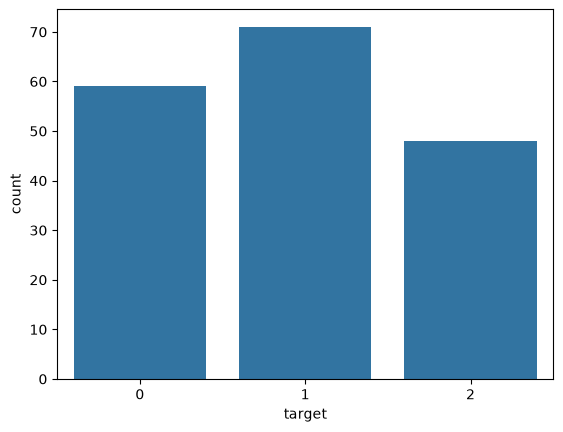

In [6]:
sns.countplot(data= df , x='target')

## 2. Train/Test Split

In [7]:
X = df.drop(['target'],axis=1)
y = df['target']

X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [8]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0
163,12.96,3.45,2.35,18.5,106.0,1.39,0.70,0.40,0.94,5.28,0.68,1.75,675.0


In [9]:
y_train.nunique()

3

## 3. Model Training

`KNeighborsClassifier` is distance-based, so features must be on the same scale first — that's why `StandardScaler` is wrapped into the same `Pipeline` rather than applied separately.

In [10]:
knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=15,metric='minkowski',p=2))
    ]
)
knn_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['alcohol','malic_acid','ash',...,'hue','od280/od315_of_diluted_wines', 'proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 4. Evaluation

In [11]:
y_pred = knn_model.predict(X_test)
y_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [12]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [13]:
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat


array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 5. Choosing k — Accuracy Across Neighbors (Euclidean Distance, `p=2`)

Sweeping `n_neighbors` from 5 to 29 to see how accuracy responds, using the default Minkowski distance with `p=2` (Euclidean).

In [15]:
#p2

performance =[]
acc =[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2))
    ]
    )
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred,average='weighted')
  recall= recall_score(y_test,y_pred,average='weighted')
  acc.append(accuracy)


  performance.append((k,(accuracy,precision,recall)))




In [16]:
print(performance)

[(5, (0.9722222222222222, 0.9747474747474748, 0.9722222222222222)), (6, (0.9722222222222222, 0.974074074074074, 0.9722222222222222)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (1.0, 1.0, 1.0)), (11, (1.0, 1.0, 1.0)), (12, (1.0, 1.0, 1.0)), (13, (1.0, 1.0, 1.0)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (1.0, 1.0, 1.0)), (16, (1.0, 1.0, 1.0)), (17, (1.0, 1.0, 1.0)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (1.0, 1.0, 1.0)), (20, (1.0, 1.0, 1.0)), (21, (1.0, 1.0, 1.0)), (22, (1.0, 1.0, 1.0)), (23, (1.0, 1.0, 1.0)), (24, (1.0, 1.0, 1.0)), (25, (1.0, 1.0, 1.0)), (26, (1.0, 1.0, 1.0)), (27, (1.0, 1.0, 1.0)), (28, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (29, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222))]


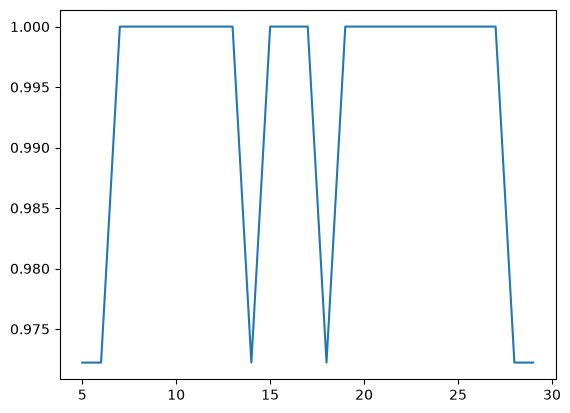

In [17]:
plt.plot(range(5,30),acc)

## 6. Choosing k — Accuracy Across Neighbors (Manhattan Distance, `p=1`)

Same sweep, but with `p=1` (Manhattan distance) instead.

In [18]:
#p1

performance =[]
acc =[]

for k in range(5,30):
  knn_model = Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=1))
    ]
    )
  knn_model.fit(X_train,y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred,average='weighted')
  recall= recall_score(y_test,y_pred,average='weighted')
  acc.append(accuracy)


  performance.append((k,(accuracy,precision,recall)))




In [19]:
print(performance)

[(5, (1.0, 1.0, 1.0)), (6, (1.0, 1.0, 1.0)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (11, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (12, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (13, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (16, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (17, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (20, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (21, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (22, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (23, 

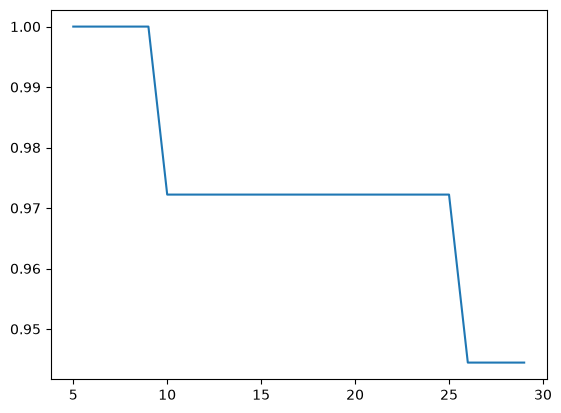

In [20]:
plt.plot(range(5,30),acc)

---
## Part 2: Real-World Uses & Hyperparameter Tuning

How KNN is used in practice, why it's fundamentally different from Logistic/Linear Regression (no learned parameters at all), and a complete, tested reference for every hyperparameter `KNeighborsClassifier` exposes — building directly on Part 1's Wine pipeline.

In [21]:
import time
from sklearn.datasets import make_classification

## 1. Where Is KNN Used? (Real-World Applications)

Anywhere "things similar to this thing" is a meaningful way to predict, KNN is a natural first choice:

| Domain | Example |
|--------|---------|
| 🎬 Recommender systems | "Users similar to you also liked..." |
| 🏥 Healthcare | Diagnosing a case by comparing it to the most similar past patients |
| 🖼️ Image / handwriting recognition | Classic baseline for digit and image classification |
| 🧬 Genomics | Classifying gene-expression patterns by similarity |
| 🕵️ Anomaly / fraud detection | A point far from all its neighbors is flagged as an outlier |
| 👷 Missing-value imputation | `KNNImputer` fills a gap with the average of the most similar rows |
| 🍷 This notebook | Classifying a wine's cultivar from its chemical measurements |

It's also a very common **baseline** for classification: it makes almost no assumptions about the data, so if a fancier model can't beat it, that's a useful signal.

## 2. Why KNN? (and Its Trade-offs)

| Reason | Plain English |
|--------|---------------|
| **No training phase** | `.fit()` just stores the data — there's no optimization loop like Part 1's `gradient_descent()` in the Logistic Regression notebook. |
| **Naturally multi-class** | No special handling needed — this notebook classifies 3 wine cultivars exactly as easily as 2 classes. |
| **Non-parametric** | Makes no assumption about the shape of the decision boundary, unlike Logistic Regression's inherently linear one. |
| **Intuitive** | "You are the average of your `k` nearest neighbors" — easy to explain to a non-technical audience. |
| **Trade-off: slow predictions** | Every prediction compares against (some or all of) the stored training data — the opposite of Logistic Regression's one-dot-product prediction. |
| **Trade-off: scale-sensitive** | Distances are meaningless if one feature ranges in the thousands and another in single digits — `StandardScaler` (Part 1, Section 3) isn't optional here. |
| **Trade-off: struggles in high dimensions** | The "curse of dimensionality" — see Section 7. |

## 3. Parameters vs. Hyperparameters — a Special Case for KNN

In the Logistic Regression notebook, training *produces* something (`W`, `b` / `coef_`, `intercept_`) that hyperparameters (`C`, `solver`, ...) merely help search for. **KNN breaks this pattern entirely:**

| | Logistic / Linear Regression ("eager learner") | KNN ("lazy learner") |
|---|---|---|
| What `.fit()` produces | Learned weights (`coef_`, `intercept_`) | Nothing — just the stored training data (and optionally a search tree) |
| Prediction cost | Cheap — one dot product | Expensive — compare against neighbors *every single time* |
| `n_neighbors`, `weights`, `metric`, ... | N/A | **All hyperparameters** — there is nothing else to learn |

That's why the rest of this part is entirely about hyperparameters — for KNN, that's the whole story.

## 4. Hyperparameter — `n_neighbors` (k)

The single most important hyperparameter. It controls the classic bias-variance trade-off:

- **Small `k`** (e.g. `1`) → low bias, high variance → the model follows every quirk of the training data (can overfit).
- **Large `k`** (approaching the size of the training set) → high bias, low variance → predictions get washed out toward the overall majority class (underfits).

Let's watch the train/test accuracy gap change across a wide range of `k`:

In [22]:
for k in [1, 5, 15, 50, 100]:
    model_k = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=k))])
    model_k.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model_k.predict(X_train))
    test_acc = accuracy_score(y_test, model_k.predict(X_test))
    print(f"k={k:<4} train_acc={train_acc:.3f}  test_acc={test_acc:.3f}  gap={train_acc - test_acc:.3f}")

k=1    train_acc=1.000  test_acc=0.972  gap=0.028
k=5    train_acc=0.979  test_acc=0.972  gap=0.007
k=15   train_acc=0.979  test_acc=1.000  gap=-0.021
k=50   train_acc=0.965  test_acc=0.917  gap=0.048


k=100  train_acc=0.718  test_acc=0.722  gap=-0.004


At `k=1`, training accuracy is a perfect `1.000` while test accuracy is slightly lower — the textbook overfitting signature, though mild here because Wine's three classes are already quite well separated. The clearer story is at the other end: by `k=100` (out of only 142 training rows), **both** train and test accuracy collapse together to around `0.72` — the model has run out of "local" structure to use and is underfitting badly. This lines up with Part 1's own sweep (Sections 5-6): both `p=1` and `p=2` found a wide plateau of good `k` values roughly between 7 and 27, with accuracy dropping off outside that range.

## 5. Hyperparameter — `weights`

Once the `k` nearest neighbors are found, how much does each one get to "vote"?

| Value | Effect |
|---|---|
| `'uniform'` (default) | Every one of the `k` neighbors gets an equal vote. |
| `'distance'` | Closer neighbors get a bigger vote, weighted by `1 / distance`. |

Let's compare both across a few values of `k`:

In [23]:
for k in [5, 15, 29]:
    for w in ['uniform', 'distance']:
        model_w = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=k, weights=w))])
        model_w.fit(X_train, y_train)
        acc = accuracy_score(y_test, model_w.predict(X_test))
        print(f"k={k:<4} weights={w:<10} test_acc={acc:.3f}")

k=5    weights=uniform    test_acc=0.972
k=5    weights=distance   test_acc=0.972
k=15   weights=uniform    test_acc=1.000
k=15   weights=distance   test_acc=1.000
k=29   weights=uniform    test_acc=0.972
k=29   weights=distance   test_acc=0.972


On this dataset, `'distance'` makes **no measurable difference** over `'uniform'` at any of these `k` values — an honest result, not a cherry-picked one. `weights` tends to matter more on noisier data, or once `k` is large enough that some of the "neighbors" being counted are meaningfully farther away than others; on Wine's clean, well-separated classes, the nearest points already agree with each other regardless of how much say each one gets.

## 6. Hyperparameter — `metric` and `p` (the Distance Function)

Part 1 (Sections 5-6) already compared `p=1` (Manhattan) against `p=2` (Euclidean) — `p` is just an exponent inside the default `metric='minkowski'`. But `metric` also accepts other named distances directly. Let's compare a few:

In [24]:
for metric in ['euclidean', 'manhattan', 'chebyshev', 'cosine', 'minkowski']:
    model_m = Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=15, metric=metric))])
    model_m.fit(X_train, y_train)
    acc = accuracy_score(y_test, model_m.predict(X_test))
    print(f"metric={metric:<12} test_acc={acc:.3f}")

metric=euclidean    test_acc=1.000
metric=manhattan    test_acc=0.972
metric=chebyshev    test_acc=0.944
metric=cosine       test_acc=1.000
metric=minkowski    test_acc=1.000


`euclidean`, `cosine`, and the default `minkowski` (which is Euclidean at `p=2`) all reach `1.000`; `manhattan` is close behind at `0.972`; `chebyshev` (distance = the single largest coordinate difference) does noticeably worse at `0.944`. Distance choice changes which points count as "close," and it's worth trying a few — there's no universal best metric.

## 7. Hyperparameter — `algorithm` (and Why Dimensionality Matters)

`algorithm` picks *how* the neighbor search is actually carried out:

| Value | Strategy |
|---|---|
| `'brute'` | Compare the query point against every single stored point. Always correct, simple. |
| `'kd_tree'` | Partition space into a tree so most far-away points can be skipped entirely. |
| `'ball_tree'` | Similar idea to `kd_tree`, using nested hyperspheres instead of axis-aligned boxes — often better in higher dimensions than `kd_tree`, though still subject to the same curse. |
| `'auto'` (default) | Inspects the data and picks whichever of the above should be fastest. |

**Important:** all four give *identical predictions* — `algorithm` only changes **speed**, never the answer. Wine only has 142 training rows, too small to measure speed differences meaningfully, so let's switch to a larger synthetic dataset (`make_classification`) and test two feature-count regimes:

In [25]:
for n_features in [5, 20]:
    print(f"--- {n_features} features ---")
    X_big, y_big = make_classification(n_samples=20000, n_features=n_features,
                                        n_informative=min(4, n_features), n_redundant=0,
                                        n_classes=3, random_state=42)
    Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_big, y_big, test_size=0.2, random_state=42)

    preds = {}
    for algo in ['brute', 'kd_tree', 'ball_tree', 'auto']:
        best_time = float('inf')
        for _ in range(3):  # best-of-3 to smooth out first-call / system noise
            model_algo = KNeighborsClassifier(n_neighbors=15, algorithm=algo)
            t0 = time.perf_counter()
            model_algo.fit(Xb_train, yb_train)
            pred = model_algo.predict(Xb_test)
            t1 = time.perf_counter()
            best_time = min(best_time, t1 - t0)
        preds[algo] = pred
        print(f"  algorithm={algo:<10} best-of-3 time={best_time:.3f}s")
    print("  brute == kd_tree predictions identical:", np.array_equal(preds['brute'], preds['kd_tree']))

--- 5 features ---


  algorithm=brute      best-of-3 time=0.091s


  algorithm=kd_tree    best-of-3 time=0.068s


  algorithm=ball_tree  best-of-3 time=0.286s
  algorithm=auto       best-of-3 time=0.068s
  brute == kd_tree predictions identical: True
--- 20 features ---


  algorithm=brute      best-of-3 time=0.103s


  algorithm=kd_tree    best-of-3 time=2.143s


  algorithm=ball_tree  best-of-3 time=1.608s


  algorithm=auto       best-of-3 time=0.104s
  brute == kd_tree predictions identical: True


With timing noise smoothed out (best-of-3 per configuration), the honest picture at 20,000 samples is: at **5 features**, `kd_tree` is modestly faster than `brute` (~1.4x) while `ball_tree` is actually *slower* than `brute` here — the tree's partitioning helps a little at low dimensions, but not dramatically, and its benefit depends on the implementation. At **20 features**, the picture reverses sharply: both `kd_tree` and `ball_tree` become roughly **14-20x slower** than `brute`, because in higher dimensions almost every point ends up roughly equidistant from the query, so the tree can no longer prune away many candidates — pure partitioning overhead with none of the benefit. In both regimes, `'auto'` matched whichever option was actually fastest, which is exactly why leaving `algorithm='auto'` alone is the right default almost always.

(This is also a good reminder that micro-benchmarks are noisy: an earlier single-shot version of this same measurement showed `brute` spiking far above its usual time on its first call, before settling down — always time the best of several repeats rather than trusting one measurement.)

## 8. Hyperparameter — `leaf_size`

Only relevant when `algorithm` is `'kd_tree'` or `'ball_tree'` (ignored by `'brute'`): it controls when the tree stops splitting and falls back to brute-force search inside a small "leaf" of points. Smaller values build a more finely-partitioned tree (more build time, potentially faster queries); larger values build faster but coarser. It **never changes the predictions** — only speed and memory:

In [26]:
base_pred = None
for leaf_size in [1, 30, 100]:
    model_leaf = KNeighborsClassifier(n_neighbors=15, algorithm='kd_tree', leaf_size=leaf_size)
    model_leaf.fit(Xb_train, yb_train)
    pred = model_leaf.predict(Xb_test)
    if base_pred is None:
        base_pred = pred
        print(f"leaf_size={leaf_size:<5} -> baseline")
    else:
        print(f"leaf_size={leaf_size:<5} -> predictions identical to baseline: {np.array_equal(pred, base_pred)}")

leaf_size=1     -> baseline


leaf_size=30    -> predictions identical to baseline: True


leaf_size=100   -> predictions identical to baseline: True


## 9. `metric_params` and `n_jobs` (Brief)

- **`metric_params`** — a dict of extra keyword arguments for metrics that need them (e.g. a custom weight vector for a weighted Minkowski distance, or a covariance matrix for Mahalanobis distance). Not needed for any of the named metrics used above.
- **`n_jobs`** — parallelizes the neighbor search across CPU cores. A pure speed knob — it never changes which neighbors are found or what gets predicted.

## 10. Quick Reference — Which Hyperparameter Matters Most?

| Priority | Hyperparameter | When it matters |
|---|---|---|
| 🥇 1st | **`n_neighbors`** | Always — the main bias/variance knob. |
| 🥈 2nd | **`metric`** (and `p`) | When your features don't suit plain Euclidean distance. |
| 🥉 3rd | **`weights`** | Noisier datasets, or large `k` where some "neighbors" are much farther than others. |
| 4th | **`algorithm`** | Only for speed on larger datasets — check dimensionality first (Section 7). |
| Rarely | `leaf_size`, `metric_params`, `n_jobs` | Pure performance tuning — never change *what* gets predicted. |

**One-line summary:** tune `n_neighbors` first, reach for `metric` if the feature space calls for it, and only touch `algorithm`/`leaf_size` once you have a dataset large enough for speed to actually matter.

## 11. The Complete List (Every Hyperparameter, Pulled From the Installed Library)

`KNeighborsClassifier` has far fewer knobs than `LogisticRegression` — just eight in total, and Sections 4-9 above already covered every one of them. Let's confirm that directly from the installed library with `inspect.signature`, so nothing is left out:

In [27]:
import inspect
import sklearn

print("scikit-learn version:", sklearn.__version__)
print()
sig = inspect.signature(KNeighborsClassifier.__init__)
for name, param in sig.parameters.items():
    if name == 'self':
        continue
    print(f"{name:<15} default = {param.default!r}")

scikit-learn version: 1.9.0

n_neighbors     default = 5
weights         default = 'uniform'
algorithm       default = 'auto'
leaf_size       default = 30
p               default = 2
metric          default = 'minkowski'
metric_params   default = None
n_jobs          default = None


That's the whole list — `n_neighbors`, `weights`, `algorithm`, `leaf_size`, `p`, `metric`, `metric_params`, `n_jobs`. Unlike `LogisticRegression`'s deprecated `penalty`/evolving `l1_ratio`, none of these are currently deprecated in this installed version — but as always, defaults can shift between scikit-learn releases, so this cell's live output reflects whatever is installed when it's last run.

---
# Summary & Key Takeaways

1. **The model**: KNN classifies a new point by majority vote among its `k` closest stored training points — there's no training phase and no learned weights.

2. **The pipeline** (Part 1): load the Wine dataset (3 classes), split with `stratify=y`, scale with `StandardScaler` (mandatory for any distance-based model), fit `KNeighborsClassifier`, and evaluate with accuracy, a confusion matrix, and a classification report.

3. **Parameters vs. hyperparameters** (Part 2, Section 3): KNN is a "lazy learner" — literally everything about it (`n_neighbors`, `weights`, `metric`, `algorithm`, ...) is a hyperparameter you choose. There's nothing analogous to Logistic/Linear Regression's learned `coef_`/`intercept_`.

4. **Tuning priority**: `n_neighbors` first (the bias/variance trade-off), then `metric` if the feature space calls for it, then `weights`/`algorithm` for the rest.

5. **The curse of dimensionality, measured directly** (Section 7): `kd_tree` was only modestly faster than brute-force at 5 features (and `ball_tree` was actually slower), but both became roughly 14-20x *slower* than brute-force at 20 features. `algorithm='auto'` correctly picked the faster option in both cases, which is why it's the safe default.

6. **Part 1's own k-sweep** (Sections 5-6) already showed both `p=1` and `p=2` finding a wide plateau of `k` values (roughly 7-27) that reach 100% test accuracy on this clean, well-separated dataset — consistent with Section 4's finding that only the extremes (`k=1` and `k=100`) show any real bias/variance trouble here.